In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import joblib

In [3]:
df = pd.read_csv('../dataset/Loan_Default_Clean_Balanced_5050.csv')
print("Dataset loaded, shape:", df.shape)

Dataset loaded, shape: (73278, 29)


In [4]:
# Isolate numeric features. Exclude 'ID', 'year', 'Status' (Target) 
# and categorical fields.
numeric_cols = [
    'loan_amount', 'property_value', 'income', 
    'Credit_Score', 'LTV', 'dtir1', 'term'
]

# Note: We excluded rate_of_interest and Upfront_charges to prevent 
# clustering purely on approved vs rejected traits.

X_cluster = df[numeric_cols].copy()

# Fill Missing Values (K-Means fails on NaNs)
for col in numeric_cols:
    X_cluster[col] = X_cluster[col].fillna(X_cluster[col].median())

# Fit a FRESH scaler explicitly for clustering
cluster_scaler = StandardScaler()
X_scaled = cluster_scaler.fit_transform(X_cluster)

print("Clustering features shape:", X_scaled.shape)

Clustering features shape: (73278, 7)


k=2 inertia=434022
k=3 inertia=372094
k=4 inertia=314302
k=5 inertia=275198
k=6 inertia=251062


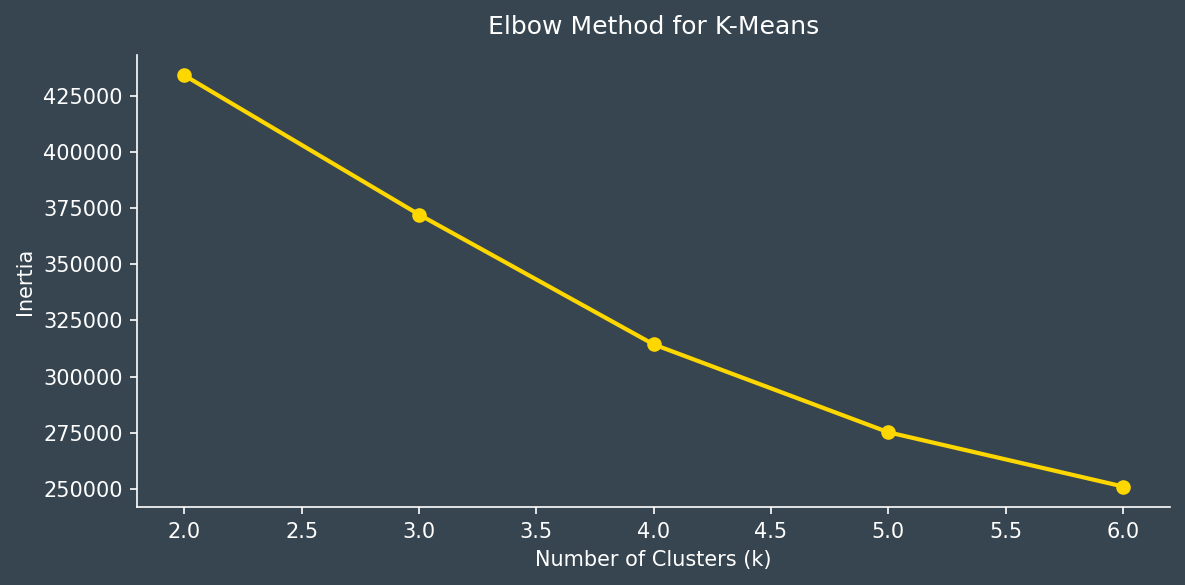

In [5]:
inertias = []
k_range = range(2, 7)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    print(f"k={k} inertia={km.inertia_:.0f}")

# Charcoal/Gold styling
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(8, 4), dpi=150)
fig.patch.set_facecolor('#36454F')
ax.set_facecolor('#36454F')

ax.plot(list(k_range), inertias, marker='o', color='#FFD700', linewidth=2)
ax.set_title('Elbow Method for K-Means', color='white', pad=10)
ax.set_xlabel('Number of Clusters (k)', color='white')
ax.set_ylabel('Inertia', color='white')
ax.tick_params(colors='white')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [6]:
K_FINAL = 4

kmeans = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

print("Cluster Population:")
print(df['Cluster'].value_counts().sort_index())

# Calculate Centroids in Original Scale for Interpretability
centroids_original = cluster_scaler.inverse_transform(kmeans.cluster_centers_)
cluster_profiles = pd.DataFrame(centroids_original, columns=numeric_cols)
cluster_profiles.index.name = 'Cluster'
print("\nCluster Profiles (Centroids):")
display(cluster_profiles.round(2))

# Save the models for your Web App!
joblib.dump(kmeans, '../cluster_model.pkl')
joblib.dump(cluster_scaler, '../cluster_scaler.pkl') # Keep this separate from your classification scaler
print("\nExported cluster_model.pkl and cluster_scaler.pkl")

Cluster Population:
Cluster
0    16249
1     9490
2    47536
3        3
Name: count, dtype: int64

Cluster Profiles (Centroids):


,loan_amount,property_value,income,Credit_Score,LTV,dtir1,term
Cluster,,,,,,,
0,581113.55,844704.87,11618.48,702.17,69.88,36.84,354.51
1,234275.55,400243.41,6863.01,700.38,66.68,36.59,193.65
2,259097.43,355754.58,4879.34,699.40,76.92,39.75,356.74
3,526500.00,8000.00,5460.00,561.33,6581.25,40.00,360.00



Exported cluster_model.pkl and cluster_scaler.pkl


In [7]:
# Reduce dimensions to 2D
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

df['PCA_X'] = X_pca[:, 0]
df['PCA_Y'] = X_pca[:, 1]

print("Explained variance ratio:", pca.explained_variance_ratio_)

# Save PCA model so the frontend can project new applicants onto the same map
joblib.dump(pca, '../pca_model.pkl')
print("Exported pca_model.pkl")

Explained variance ratio: [0.28768067 0.17238915]
Exported pca_model.pkl


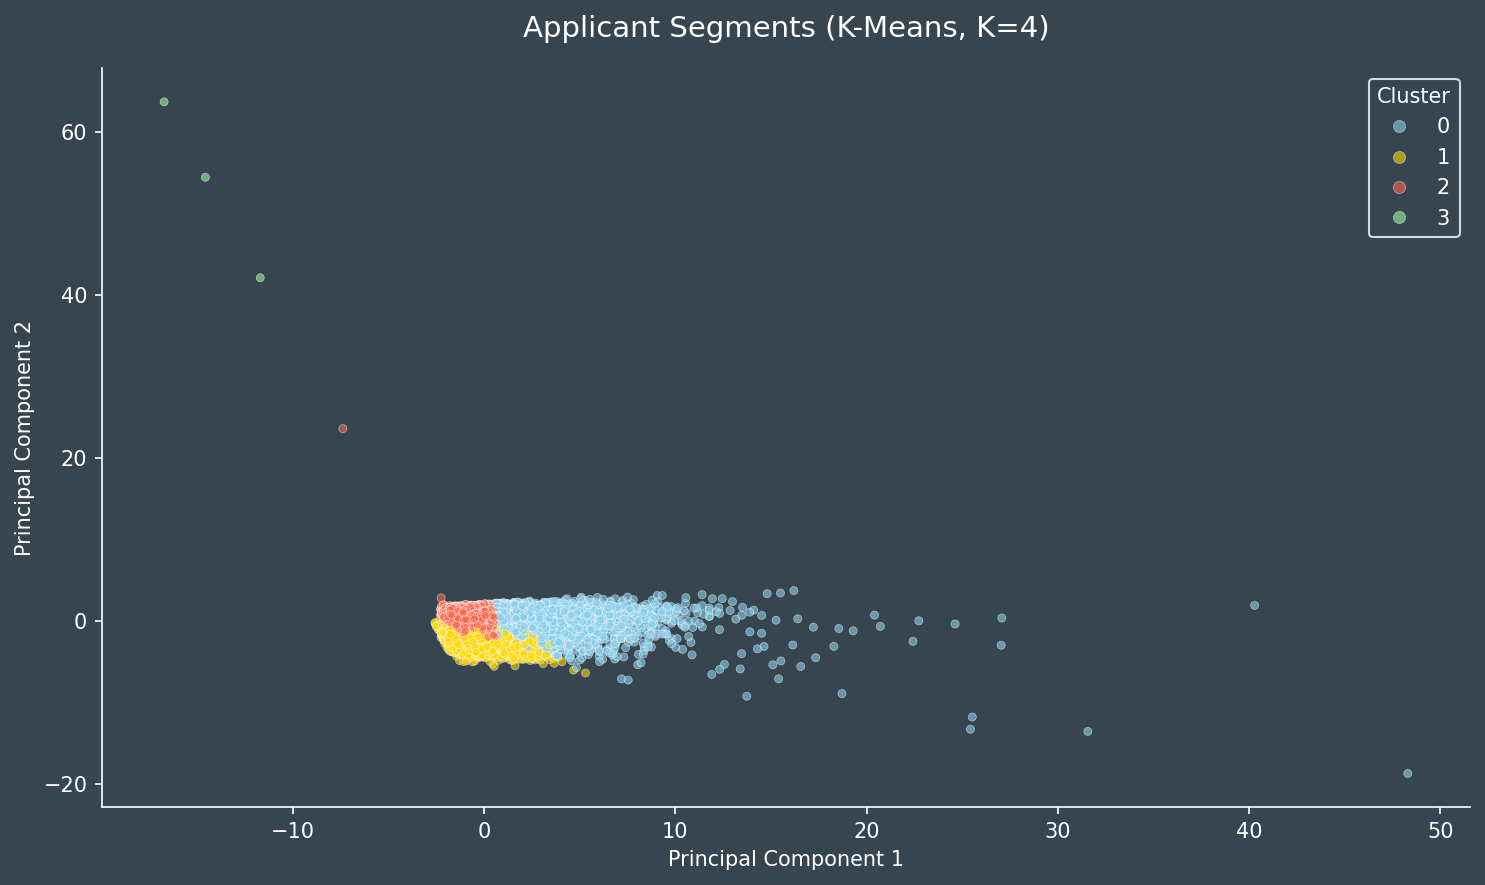

In [9]:
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(10, 6), dpi=150)
fig.patch.set_facecolor('#36454F')
ax.set_facecolor('#36454F')

# Professional palette mapping 4 clusters
cluster_palette = ['#87CEEB', '#FFD700', '#FF6347', '#98FB98'] 

sns.scatterplot(
    x='PCA_X', y='PCA_Y', 
    hue='Cluster', 
    palette=cluster_palette, 
    data=df, 
    alpha=0.6, 
    s=15, 
    ax=ax
)

plt.title(f'Applicant Segments (K-Means, K={K_FINAL})', color='white', fontsize=14, pad=15)
ax.set_xlabel('Principal Component 1', color='white')
ax.set_ylabel('Principal Component 2', color='white')
ax.tick_params(colors='white')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

legend = ax.legend(title='Cluster', facecolor='#36454F', edgecolor='white', markerscale=1.5)
plt.setp(legend.get_texts(), color='white')

plt.tight_layout()
plt.savefig('../reports/clustering_map.png', facecolor=fig.get_facecolor(), edgecolor='none')
plt.show()

# Finally, save the dataframe with cluster labels for future analysis
df.to_csv('../dataset/Loan_Default_Clustered.csv', index=False)